# 02 · Clean the NHATS Data

This notebook keeps the cleaning review short and auditable. The actual cleaning code lives in `src/willow/nhats.py`,
`nhats_extra.py`, `dementia.py`, and `config/variables.yaml`; the notebook checks the decisions and writes aggregate
artifacts for the project.

Outputs: local respondent data at `data/clean/panel.parquet`, plus shareable aggregate files
`results/data_dictionary.csv` and `results/cleaning_log.md`.

NHATS rule for this notebook: show only aggregate counts, percentages, and summaries. Do not display individual rows.


In [9]:
import datetime
import os
import sys
from pathlib import Path

for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (root / "src" / "willow").exists():
        sys.path.insert(0, str(root / "src"))
        break
for name in list(sys.modules):
    if name == "willow" or name.startswith("willow."):
        del sys.modules[name]

import pandas as pd
import matplotlib.pyplot as plt

from willow import dementia, nhats, explore as ex, interpret
from willow.data import DEFAULT_NHATS, PANEL_CACHE, ROOT, load_panel
from willow.features import build_windows
from willow.schema import EXTRA_NUMERIC

NHATS_DIR = DEFAULT_NHATS
cfg = nhats.load_config()
pd.set_option("display.max_columns", 40, "display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
YEAR = {r: 2010 + r for r in range(1, 30)}


## 1. Raw Inputs And Missing Codes

Load only the raw SP columns used by the cleaner. Negative NHATS codes are reasons for missingness, not numeric values;
`-1` is recoded only where the skip pattern means “no.”


In [10]:
rounds = nhats.rounds_available(NHATS_DIR, cfg)
raw = {r: nhats.load_raw_round(NHATS_DIR, r, cfg) for r in rounds}
templates = {name: spec["nhats"] for name, spec in cfg["items"].items() if "nhats" in spec}
print(f"rounds {rounds}; {sum(len(d) for d in raw.values()):,} SP records loaded in memory")
ex.code_classes(raw, templates).sort_values("valid %").iloc[:25]


rounds [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]; 89,087 SP records loaded in memory


,valid %,-1 inapplicable %,-7 refused %,-8 don't know %,-9 missing %,not in file %
item,,,,,,
eating_wout,8.42,89.49,0.02,0.03,2.05,0.00
bathing_wout,18.47,79.42,0.00,0.06,2.05,0.00
get_around_inside_wout,20.50,77.32,0.01,0.13,2.05,0.00
get_out_of_bed_wout,21.16,76.67,0.01,0.10,2.05,0.00
dressing_wout,21.51,76.35,0.02,0.07,2.05,0.00
go_outside_wout,23.29,74.54,0.01,0.12,2.05,0.00
race_eth,35.36,0.00,0.00,0.00,0.00,64.64
female,35.36,0.00,0.00,0.00,0.00,64.64
pain_limits,49.79,48.10,0.00,0.06,2.05,0.00


## 2. Recodes To Verify

These compact crosstabs check representative core recode rules. The full list of valid raw codes that map to missing
should contain only intentional don't-know/refused/not-done variants.


In [11]:
for item in ["go_outside_help", "bathing_diff", "bathing_device", "bathing_wout", "residence"]:
    spec = cfg["items"][item]
    print()
    print(f"{item} <- {spec['nhats']} (rule: {spec['recode']})")
    display(ex.recode_check(raw, spec["nhats"], cfg["recodes"][spec["recode"]]).set_index(["raw code", "recoded"]).T)

unmapped = ex.unmapped_codes(raw, cfg)
unmapped



go_outside_help <- mo{r}douthelp (rule: help_d)


raw code,-1.0,1.0,2.0,3.0,8.0
recoded,missing,0.0,1.0,missing,0.0
n,4589,67188,13668,174,3468



bathing_diff <- sc{r}dbathsfdf (rule: sfdf)


raw code,-1.0,1.0,2.0,3.0,6.0,7.0
recoded,missing,1.0,0.0,1.0,missing,missing
n,9347,5216,64488,9871,62,103



bathing_device <- sc{r}dbathdevi (rule: devi)


...


bathing_wout <- sc{r}bathwout (rule: yes_no)


raw code,-9.0,-8.0,-1.0,1.0,2.0
recoded,missing,missing,0.0,1.0,0.0
n,1826,57,70751,2056,14397



residence <- r{r}dresid (rule: residence)


raw code,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
recoded,community,residential_care,residential_care,nursing_home,nursing_home,deceased,residential_care,nursing_home
n,73928,4671,618,1609,410,5169,798,1884


,item,recode,raw code,n set to missing
0,go_outside_help,help_d,3.0,174
1,get_around_inside_help,help_d,3.0,117
2,get_out_of_bed_help,help_d,3.0,214
3,eating_help,help_d,3.0,197
4,bathing_help,help_d,3.0,374
5,toileting_help,help_d,3.0,308
6,dressing_help,help_d,3.0,84
7,dressing_help,help_d,9.0,174
8,go_outside_diff,sfdf,4.0,14
9,go_outside_diff,sfdf,5.0,21


## 3. Derived Measures

Dementia uses the official NHATS classification. Income is used only for fairness auditing, never as an app predictor.


In [12]:
dc = dementia.check(NHATS_DIR)
print(f"{int(dc.match.sum())}/{int(dc.match.notna().sum())} published dementia counts matched exactly")
display(dc[dc.match == False])

inc = nhats.load_income(NHATS_DIR, cfg)
income_coverage = inc.groupby("round")["income"].agg(people="size", median="median", q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75)).round(-2)
income_coverage["people"] = ex.suppress(income_coverage["people"])
income_coverage


68/70 published dementia counts matched exactly


,round,code,ours,official,match
58,12,2,572,567,False
59,12,3,4657,4662,False


,people,median,q25,q75
round,,,,
1,8200,28000.0,15000.0,50000.0
3,5800,30000.0,17100.0,57900.0
5,8300,32200.0,17600.0,60000.0
7,6300,35000.0,19000.0,65000.0
9,5000,36500.0,19600.0,70000.0
11,3800,40000.0,21400.0,75000.0
12,6300,40000.0,20000.0,75000.0
13,8600,40000.0,20800.0,75000.0
14,7700,40000.0,21400.0,80000.0


## 4. Build And Check The Clean Panel

Rebuild once from raw files so this notebook verifies the current cleaning code. The checks below are aggregate-only.


In [13]:
panel = load_panel(NHATS_DIR, refresh=True)
checks = ex.consistency(panel)
display(checks)
display(interpret.age_check(panel))
ex.numeric_summary(panel, EXTRA_NUMERIC + ["age", "phq2", "go_out_freq", "self_rated_health"])


[data] built panel from NHATS in 4s -> data/clean/panel.parquet (keep local)


,check,cases
0,duplicate person-round rows,0
1,people whose sex changes across rounds,0
2,people whose race/ethnicity changes across rounds,0
3,rows after a person's death round,0
4,non-community rows that still have activity items,0
5,community rows: help reported but no difficult...,1480


,check,value
0,consecutive interview pairs checked,65479.0
1,age group went DOWN,1.0
2,age group jumped more than the gap allows,0.0
3,share of pairs consistent (%),100.0


,% missing,p1,p25,median,p75,p99
capacity_limits,1.3,0.00,0.00,2.00,6.00,10.00
n_chronic,0.0,0.00,2.00,2.00,3.00,6.00
walk_time,19.0,2.13,3.15,3.84,5.00,16.42
chair_time,33.4,5.49,9.56,11.49,13.96,27.80
grip_max,19.3,8.10,18.90,24.50,32.20,57.80
balance_score,10.7,0.00,2.00,3.00,3.00,3.00
perf_unable,8.2,0.00,0.00,0.00,0.00,3.00
network_size,4.8,0.00,1.00,2.00,3.00,5.00
bmi,2.8,17.22,23.73,26.87,30.72,45.17
age,0.0,67.00,72.00,77.00,82.00,92.00


round,1,2,3,4,5,6,7,8,9,10,11,12,13,14
variable,,,,,,,,,,,,,,
walk_time,18.0,17.3,17.0,18.8,13.9,13.5,11.7,12.6,13.7,100.0,14.0,13.6,14.6,14.5
chair_time,30.7,31.2,30.7,34.5,27.2,27.5,27.3,28.3,30.3,100.0,30.8,28.4,31.9,32.6
grip_max,17.9,17.3,17.5,18.3,14.2,13.9,12.9,13.5,14.0,100.0,15.0,13.5,14.9,15.4
balance_score,10.1,9.3,8.4,8.5,4.6,4.6,3.7,3.7,4.0,100.0,7.4,5.0,5.6,4.8
perf_unable,7.7,6.6,5.1,5.3,1.7,1.7,0.9,1.0,0.7,100.0,5.3,2.6,3.5,2.6


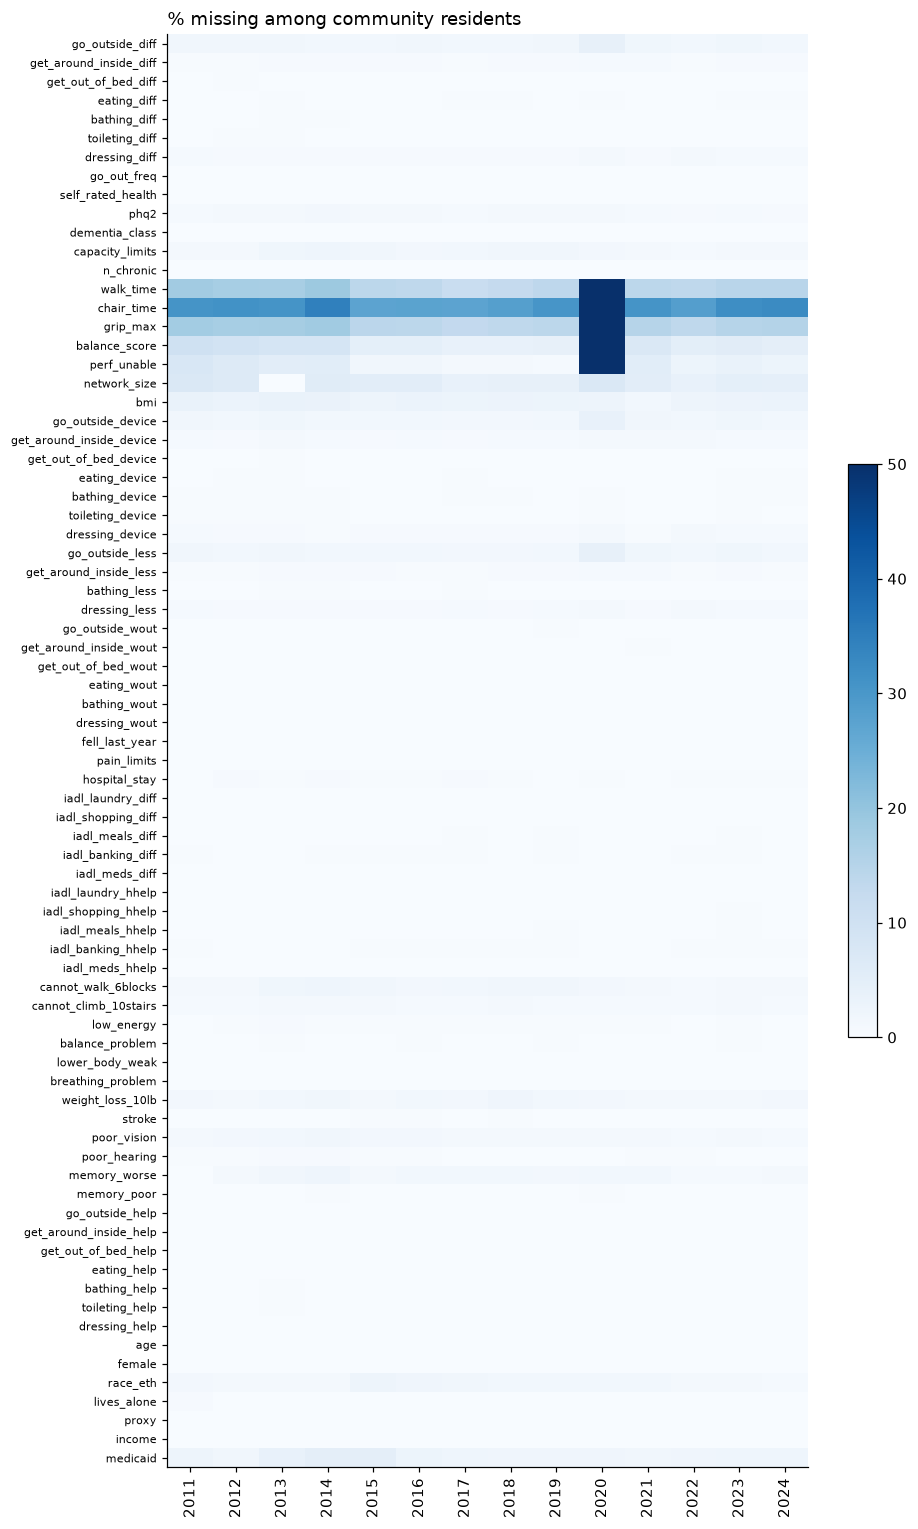

In [14]:
miss = interpret.missingness(panel)
fig, ax = plt.subplots(figsize=(9, 14))
im = ax.imshow(miss.values, aspect="auto", cmap="Blues", vmin=0, vmax=50)
ax.set_yticks(range(len(miss)), miss.index, fontsize=7)
ax.set_xticks(range(miss.shape[1]), [YEAR[r] for r in miss.columns], rotation=90)
ax.set_title("% missing among community residents", loc="left")
plt.colorbar(im, shrink=0.4)
plt.tight_layout()
miss[miss.max(axis=1) > 10]


## 5. Prediction Windows And Attrition

The cohort flow shows who remains in the analytic outcome sample. Attrition summaries help identify whether lost
follow-up could make the observed community outcome sample look healthier than the full at-risk population.


In [15]:
windows = build_windows(panel)
flow = ex.cohort_flow(panel, windows)
display(flow)
interpret.attrition(windows)


,step,n
0,"sample people, rounds 1-14",18439
1,person-rounds living in the community,73928
2,"at-risk windows: community at t-1 and t, no he...",44805
3,... died before t+1,1107
4,... moved into care before t+1,506
5,... not interviewed at t+1 (lost),7560
6,analytic windows (outcome observed at home),35632


group,died,lost to follow-up,moved to care,stayed (outcome observed)
measure (mean at t),,,,
windows,1107.000,7560.000,506.000,35632.000
share_of_at_risk_%,2.500,16.900,1.100,79.500
age,82.777,77.812,84.174,78.293
female,0.424,0.543,0.607,0.551
lives_alone,0.419,0.307,0.577,0.331
proxy,0.037,0.016,0.030,0.009
low_income,0.292,0.212,0.265,0.202
medicaid,0.163,0.154,0.127,0.112
self_rated_health__cur,3.185,2.716,2.822,2.600


## Takeaways

- The raw NHATS files are present for all rounds used here, with expected gaps for cohort-entry fields such as sex and race/ethnicity.
- Missing-data codes are handled explicitly: skip-pattern values are recoded only when they imply “no,” while refusal, don't-know, and true missing values stay missing.
- The cleaned panel passes the core consistency checks, so downstream model results are grounded in a stable person-round structure.
- Dementia, income, and extra physical/symptom measures are derived in one place and checked here so the modelling notebooks can treat them as documented inputs.
- Attrition is meaningful: people who die, move to care, or are lost before follow-up differ from those with observed community outcomes, so later sensitivity analyses should keep those exits visible.


## Save Local And Aggregate Outputs


In [16]:
os.makedirs(os.path.join(ROOT, "results"), exist_ok=True)
panel.to_parquet(PANEL_CACHE, index=False)

dd = ex.data_dictionary(panel, cfg)
dd.to_csv(os.path.join(ROOT, "results", "data_dictionary.csv"), index=False)

ex.write_cleaning_log(
    os.path.join(ROOT, "results", "cleaning_log.md"),
    built_at=f"{datetime.datetime.now():%Y-%m-%d %H:%M}",
    rounds=rounds,
    panel=panel,
    inventory=nhats.file_inventory(NHATS_DIR, cfg),
    dementia_check=dc,
    unmapped=unmapped,
    checks=checks,
    flow=flow,
)
print("saved local panel, results/data_dictionary.csv and results/cleaning_log.md")
dd.iloc[:15]


saved local panel, results/data_dictionary.csv and results/cleaning_log.md


,column,label,nhats_source,recode,dtype,% non-missing (community)
0,person_id,NHATS sample person ID,spid,,float64,100.0
1,round,NHATS round (1 = 2011 ... 14 = 2024),file,,int64,100.0
2,go_outside_help,Help from a person: go outside,mo{r}douthelp,help_d,float64,100.0
3,get_around_inside_help,Help from a person: get around inside,mo{r}dinsdhelp,help_d,float64,100.0
4,get_out_of_bed_help,Help from a person: get out of bed,mo{r}dbedhelp,help_d,float64,100.0
5,eating_help,Help from a person: eating,sc{r}deathelp,help_d,float64,100.0
6,bathing_help,Help from a person: bathing,sc{r}dbathhelp,help_d,float64,99.9
7,toileting_help,Help from a person: toileting,sc{r}dtoilhelp,help_d,float64,99.9
8,dressing_help,Help from a person: dressing,sc{r}ddreshelp,help_d,float64,99.9
9,go_outside_diff,Difficulty go outside alone,mo{r}doutsfdf,sfdf,float64,98.3
